In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

df = pd.read_csv(r"D:\data_mining\tuan6\data.csv")
df.head()
colnames = list(df.columns[1:-1])

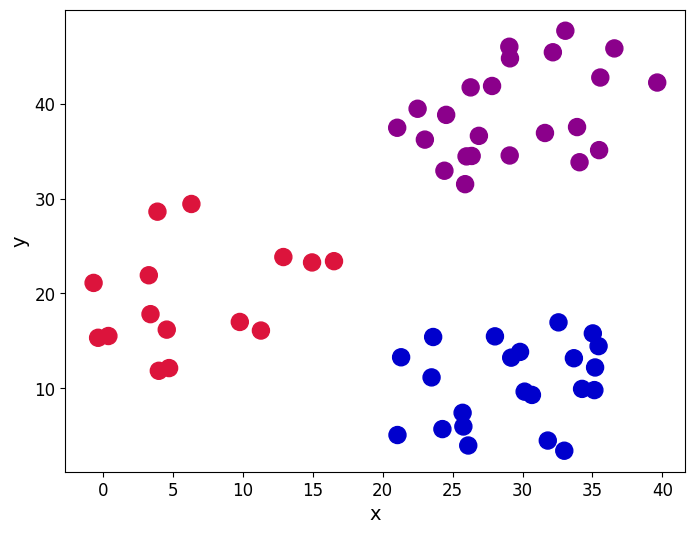

In [47]:
customcmap = ListedColormap(["crimson", "mediumblue", "darkmagenta"])
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(x=df['x'], y=df['y'], s=150,
            c=df['cluster'].astype('category'),
            cmap= customcmap)

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [48]:
def random_centroids(k, dset):
    centroids = dset.sample(k)
    return centroids

np.random.seed(42)
k = 3
centroids = random_centroids(k, df[['x', 'y']])
centroids

,x,y
0,24.412,32.932
5,25.893,31.515
36,26.878,36.609


In [49]:
def Dist(a, b):
    return np.sum(abs(a - b))

In [50]:
for i, centroid in enumerate(range(centroids.shape[0])):
    err = Dist(centroids.iloc[centroid, :], df.iloc[36, :])
    print('Error for centroid {0}: {1:.2f}'.format(i, err))

Error for centroid 0: 6.14
Error for centroid 1: 6.08
Error for centroid 2: 0.00


In [51]:
def centroid_assignation(dset, centroids):
    k = centroids.shape[0]
    n = dset.shape[0]
    assignation = []
    assign_errors = []
    for obs in range(n):

        all_errors = np.array([])
        for centroid in range(k):
            err = Dist(centroids.iloc[centroid, :], dset.iloc[obs, :])
            all_errors = np.append(all_errors, err)
        nearest_centroid = np.where(all_errors==np.amin(all_errors))[0].tolist()[0]
        nearest_centroid_error = np.amin(all_errors)
        assignation.append(nearest_centroid)
        assign_errors.append(nearest_centroid_error)
    return assignation, assign_errors

In [52]:
df['centroid'], df['error'] = centroid_assignation(df, centroids)
df.head()

,ID,x,y,cluster,centroid,error
0,0,24.412,32.932,2,0,0.000
1,1,35.190,12.189,1,1,28.623
2,2,26.288,41.718,2,2,5.699
3,3,0.376,15.506,0,0,41.462
4,4,26.116,3.963,1,1,27.775


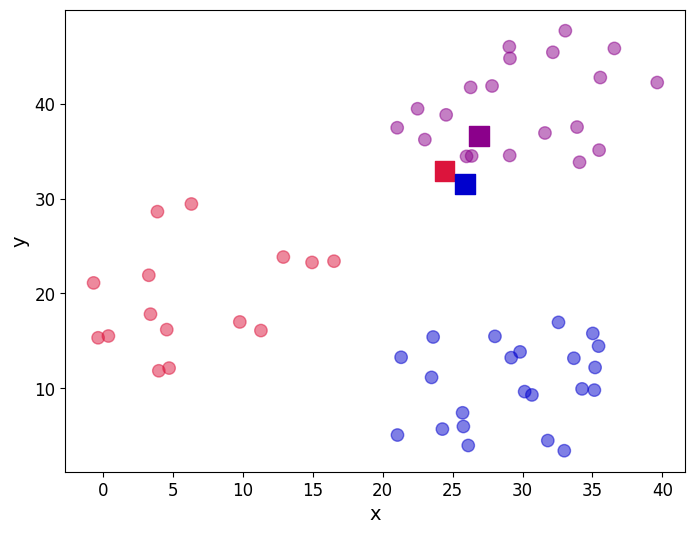

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(x=df['x'], y=df['y'],
            c=df['cluster'].astype('category'),
            cmap= customcmap, s=80, alpha=0.5)

plt.scatter(centroids.iloc[:, 0], centroids.iloc[:, 1],
            marker= 's', s=200, c=[0, 1, 2],
            cmap= customcmap)

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [54]:
print("The total error ís {0:.2f}".format(df['error'].sum()))

The total error ís 1226.24


In [55]:
centroids = df.groupby('centroid').agg('median').loc[:, colnames].reset_index(drop = True)
centroids

,x,y
0,9.776,16.179
1,30.671,12.189
2,29.091,39.144


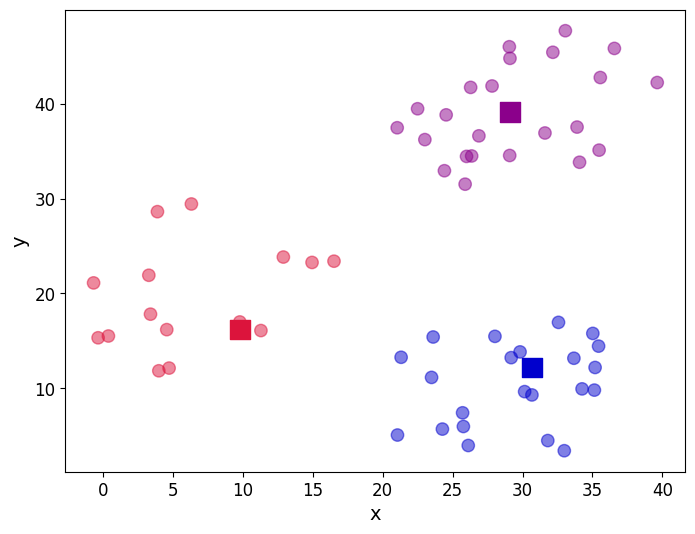

In [56]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(x=df['x'], y=df['y'],
            c=df['cluster'].astype('category'),
            cmap= customcmap, s=80, alpha=0.5)

plt.scatter(centroids.iloc[:, 0], centroids.iloc[:, 1],
            marker= 's', s=200, c=[0, 1, 2],
            cmap= customcmap)

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [57]:
def kmeadians(dset, k=2, tol=1e-4):
    working_dset = dset.copy()

    err = []
    goahead = True
    j = 0

    centroids = random_centroids(k , dset)

    while(goahead):
        working_dset['centroid'], j_err = centroid_assignation(working_dset, centroids)
        err.append(sum(j_err))

        centroids = working_dset.groupby('centroid').agg('median').reset_index(drop = True)

        if j > 0:
            if err[j - 1] - err[j] <= tol:
                goahead = False
        j += 1

    working_dset['centroid'], j_err = centroid_assignation(working_dset, centroids)
    centroids = working_dset.groupby('centroid').agg('median').reset_index(drop = True)
    return working_dset['centroid'], j_err, centroids

In [58]:
np.random.seed(42)
df['centroid'], df['error'], centroids = kmeadians(df[['x', 'y']], 3)
df.head()

,ID,x,y,cluster,centroid,error
0,0,24.412,32.932,2,2,9.2470
1,1,35.190,12.189,1,1,6.8565
2,2,26.288,41.718,2,2,6.9510
3,3,0.376,15.506,0,0,6.4780
4,4,26.116,3.963,1,1,10.4435


In [59]:
centroids

,x,y
0,4.550,17.8100
1,29.986,10.5365
2,29.056,37.5350


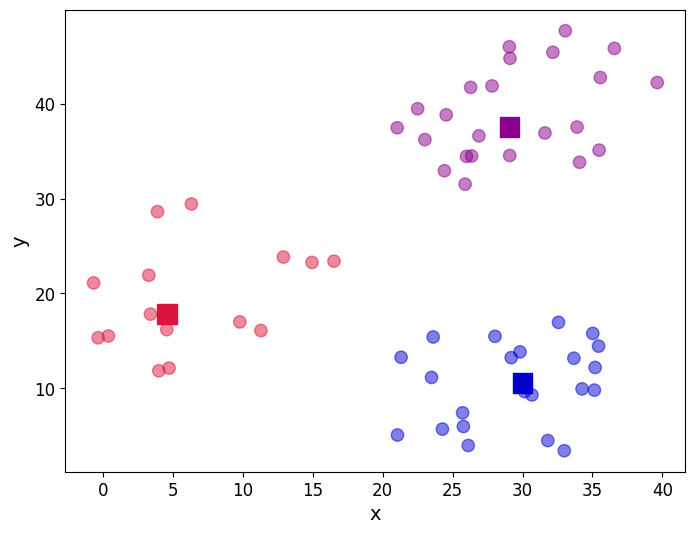

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(x=df['x'], y=df['y'],
            c=df['cluster'].astype('category'),
            cmap= customcmap, s=80, alpha=0.5)

plt.scatter(centroids.iloc[:, 0], centroids.iloc[:, 1],
            marker= 's', s=200, c=[0, 1, 2],
            cmap= customcmap)

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

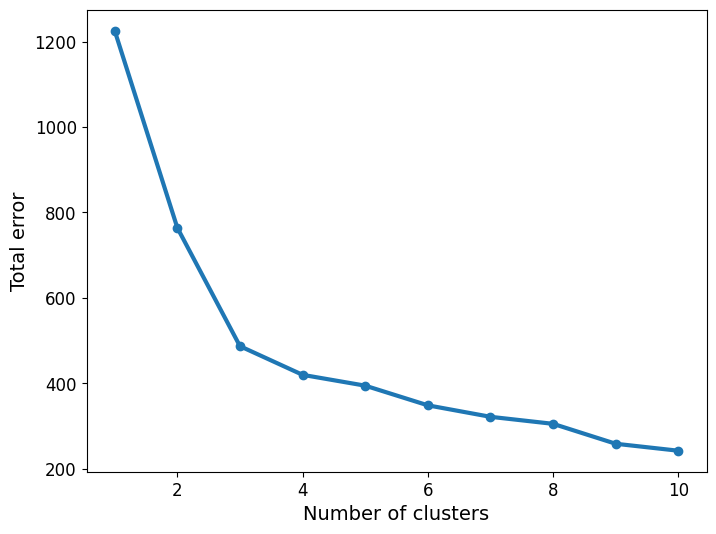

In [62]:
err_total = []
n = 10
df_elbow = df[['x', 'y']]
for i in range(n):
    _, my_errs, _ = kmeadians(df_elbow, i + 1)
    err_total.append(sum(my_errs))

fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(range(1, n+1), err_total, linewidth=3, marker='o')

ax.set_xlabel(r'Number of clusters', fontsize=14)
ax.set_ylabel(r'Total error', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()